### Default SVR


=== PER FOLD RESULTS TABLE ===
   Fold  Train_R2    Val_R2  Train_RMSE  Val_RMSE  Train_MAE   Val_MAE
0     1  0.913388  0.816860    0.106036  0.155435   0.083551  0.117013
1     2  0.914174  0.811119    0.105686  0.157050   0.083431  0.116967
2     3  0.913180  0.812419    0.106069  0.157843   0.084083  0.116705
3     4  0.915170  0.791900    0.105741  0.160614   0.083389  0.119964
4     5  0.912762  0.819728    0.106430  0.154157   0.083706  0.115577

 SVR (DEFAULT) - 5-FOLD CV (LOG SCALE)  
Metric              Train     Validation            Gap
----------------------------------------------------------------------
R²                 0.9137         0.8104         0.1033
RMSE               0.1060         0.1570               
MAE                0.0836         0.1172               

SVR (DEFAULT) - TRAIN & TEST (ORIGINAL SCALE)
Metric              Train           Test
----------------------------------------------------------------------
R²                 0.9172         0.8008
RMSE 

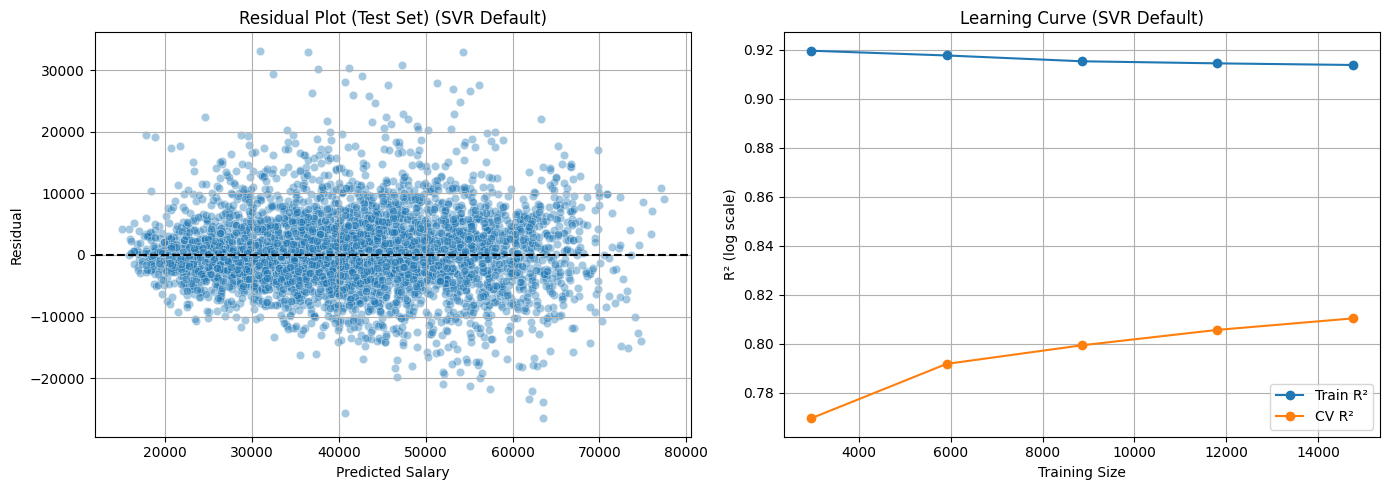

In [ ]:
import random
import warnings
import torch
import pandas as pd
import numpy as np
import pickle

from sklearn.model_selection import KFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# Machine Learning Models
from sklearn.svm import SVR

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import learning_curve


# REPRODUCIBILITY
seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

warnings.filterwarnings("ignore")

# LOAD DATA
df = pd.read_csv(
    "../Unified_Resume_Salary_Dataset.csv"
)

with open("../master_vocab.pkl", "rb") as f:
    master_vocab = pickle.load(f)

train_idx = np.load("../train_idx.npy")
test_idx  = np.load("../test_idx.npy")

X_text = df["Aligned_Text"]
y = df["Log_Salary"]

X_train = X_text.iloc[train_idx]
X_test  = X_text.iloc[test_idx]
y_train = y.iloc[train_idx].values
y_test  = y.iloc[test_idx].values

# PIPELINE
tfidf_config = dict(
    vocabulary=master_vocab,
    ngram_range=(1, 3),
    token_pattern=r'(?u)\.?[a-z0-9][a-z0-9\+\#\.]*',
    norm=None,
    binary=True,
    min_df=5
)

model = Pipeline([
    ("tfidf", TfidfVectorizer(**tfidf_config)),
    ("model", SVR())
])

# CROSS VALIDATION SETUP
cv = KFold(n_splits=5, shuffle=True, random_state=seed)

scoring = {
    "r2": "r2",
    "rmse": "neg_root_mean_squared_error",
    "mae": "neg_mean_absolute_error"
}

# RUN CROSS VALIDATION
cv_results = cross_validate(
    model,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring,
    return_train_score=True,
    n_jobs=-1
)

# PER-FOLD RESULTS TABLE
fold_df = pd.DataFrame({
    "Fold": np.arange(1, cv.get_n_splits() + 1),

    "Train_R2": cv_results["train_r2"],
    "Val_R2": cv_results["test_r2"],

    "Train_RMSE": -cv_results["train_rmse"],
    "Val_RMSE": -cv_results["test_rmse"],

    "Train_MAE": -cv_results["train_mae"],
    "Val_MAE": -cv_results["test_mae"]
})

print("\n=== PER FOLD RESULTS TABLE ===")
print(fold_df)

# METRICS (LOG SCALE - CV ONLY)
cv_train_r2 = np.mean(cv_results["train_r2"])
cv_val_r2   = np.mean(cv_results["test_r2"])

cv_train_rmse = -np.mean(cv_results["train_rmse"])
cv_val_rmse   = -np.mean(cv_results["test_rmse"])

cv_train_mae = -np.mean(cv_results["train_mae"])
cv_val_mae   = -np.mean(cv_results["test_mae"])

gap = cv_train_r2 - cv_val_r2

# PRINT PER MODEL SUMMARY
print("\n" + "="*70)
print(f"{'SVR (DEFAULT) - 5-FOLD CV (LOG SCALE)':^40}")
print("="*70)
print(f"{'Metric':<10}{'Train':>15}{'Validation':>15}{'Gap':>15}")
print("-"*70)
print(f"{'R²':<10}{cv_train_r2:>15.4f}{cv_val_r2:>15.4f}{gap:>15.4f}")
print(f"{'RMSE':<10}{cv_train_rmse:>15.4f}{cv_val_rmse:>15.4f}{'':>15}")
print(f"{'MAE':<10}{cv_train_mae:>15.4f}{cv_val_mae:>15.4f}{'':>15}")
print("="*70)

# TRAIN FINAL MODEL ON FULL TRAIN SET
model.fit(X_train, y_train)

# Predictions (LOG SCALE)
train_pred_log = model.predict(X_train)
test_pred_log  = model.predict(X_test)

# INVERSE TRANSFORM (BACK TO ORIGINAL SALARY)
train_pred = np.expm1(train_pred_log)
test_pred  = np.expm1(test_pred_log)

y_train_actual = np.expm1(y_train)
y_test_actual  = np.expm1(y_test)

# METRICS (ORIGINAL SCALE)
train_r2_orig = r2_score(y_train_actual, train_pred)
test_r2_orig  = r2_score(y_test_actual, test_pred)

train_rmse_orig = np.sqrt(mean_squared_error(y_train_actual, train_pred))
test_rmse_orig  = np.sqrt(mean_squared_error(y_test_actual, test_pred))

train_mae_orig = mean_absolute_error(y_train_actual, train_pred)
test_mae_orig  = mean_absolute_error(y_test_actual, test_pred)

# PRINT
print("\n" + "="*70)
print(f"{'SVR (DEFAULT) - TRAIN & TEST (ORIGINAL SCALE)':^40}")
print("="*70)
print(f"{'Metric':<10}{'Train':>15}{'Test':>15}")
print("-"*70)
print(f"{'R²':<10}{train_r2_orig:>15.4f}{test_r2_orig:>15.4f}")
print(f"{'RMSE':<10}{train_rmse_orig:>15,.2f}{test_rmse_orig:>15,.2f}")
print(f"{'MAE':<10}{train_mae_orig:>15,.2f}{test_mae_orig:>15,.2f}")
print("="*70)


# PLOTS
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Residual Plot (ORIGINAL SCALE) ---
residuals = y_test_actual - test_pred

sns.scatterplot(
    x=test_pred,
    y=residuals,
    alpha=0.4,
    ax=axes[0]
)

axes[0].axhline(0, linestyle='--', color='black')
axes[0].grid(True)
axes[0].set_title("Residual Plot (Test Set) (SVR Default)")
axes[0].set_xlabel("Predicted Salary")
axes[0].set_ylabel("Residual")

# --- Learning Curve (LOG SCALE) ---
train_sizes, train_scores, val_scores = learning_curve(
    model,                 
    X_train,
    y_train,
    cv=cv,
    scoring="r2",
    train_sizes=np.linspace(0.2, 1.0, 5),
    n_jobs=-1
)

axes[1].plot(
    train_sizes,
    np.mean(train_scores, axis=1),
    marker='o',
    label="Train R²"
)

axes[1].plot(
    train_sizes,
    np.mean(val_scores, axis=1),
    marker='o',
    label="CV R²"
)

axes[1].grid(True)
axes[1].set_title("Learning Curve (SVR Default)")
axes[1].set_xlabel("Training Size")
axes[1].set_ylabel("R² (log scale)")
axes[1].legend()

plt.tight_layout()
plt.show()

### Hyperparameter-tuned SVR

[I 2026-05-06 03:47:09,802] A new study created in memory with name: no-name-c29a7bd1-9a17-44ca-92a9-d365ea7ce53a



>>> Starting Trial #0...


[I 2026-05-06 03:48:15,173] Trial 0 finished with value: 0.7920982339445173 and parameters: {'C': 0.5548560531710345, 'epsilon': 0.17531553087916182, 'gamma': 0.005829128701336153}. Best is trial 0 with value: 0.7920982339445173.
[I 2026-05-06 03:49:23,921] Trial 1 finished with value: 0.7961886733285524 and parameters: {'C': 0.5233645124318038, 'epsilon': 0.16198801198698362, 'gamma': 0.005665476991575289}. Best is trial 1 with value: 0.7961886733285524.
[I 2026-05-06 03:50:33,411] Trial 2 finished with value: 0.7962186931445215 and parameters: {'C': 0.4965151733964184, 'epsilon': 0.16059594268679603, 'gamma': 0.0053036246355577885}. Best is trial 2 with value: 0.7962186931445215.
[I 2026-05-06 03:51:32,693] Trial 3 finished with value: 0.7884198614799279 and parameters: {'C': 0.5688665549961351, 'epsilon': 0.18382619784717935, 'gamma': 0.004784385276163986}. Best is trial 2 with value: 0.7962186931445215.
[I 2026-05-06 03:52:34,302] Trial 4 finished with value: 0.7901321885088535 and


>>> Starting Trial #10...


[I 2026-05-06 03:59:01,666] Trial 10 finished with value: 0.7941623234182671 and parameters: {'C': 0.45703560882052874, 'epsilon': 0.16702327547390775, 'gamma': 0.0061759541730679254}. Best is trial 2 with value: 0.7962186931445215.
[I 2026-05-06 04:00:12,081] Trial 11 finished with value: 0.7969547779611343 and parameters: {'C': 0.5249147581091154, 'epsilon': 0.15949312624762257, 'gamma': 0.005658185889358389}. Best is trial 11 with value: 0.7969547779611343.
[I 2026-05-06 04:01:24,369] Trial 12 finished with value: 0.7982900045827821 and parameters: {'C': 0.5242913913034878, 'epsilon': 0.15533317822459547, 'gamma': 0.005870518825197794}. Best is trial 12 with value: 0.7982900045827821.
[I 2026-05-06 04:02:36,660] Trial 13 finished with value: 0.7982844571155712 and parameters: {'C': 0.5325468625537466, 'epsilon': 0.1555002910887873, 'gamma': 0.005925133555684528}. Best is trial 12 with value: 0.7982900045827821.
[I 2026-05-06 04:03:49,063] Trial 14 finished with value: 0.798402260261

...


>>> Starting Trial #80...


[I 2026-05-06 05:23:19,698] Trial 80 finished with value: 0.7975809853188087 and parameters: {'C': 0.5425742557508626, 'epsilon': 0.15800944945938247, 'gamma': 0.0061222828765978374}. Best is trial 60 with value: 0.7984555132495139.
[I 2026-05-06 05:24:32,230] Trial 81 finished with value: 0.7983238848124183 and parameters: {'C': 0.5346007122556058, 'epsilon': 0.1550564754877312, 'gamma': 0.005560924252849729}. Best is trial 60 with value: 0.7984555132495139.
[I 2026-05-06 05:25:44,501] Trial 82 finished with value: 0.7981576737858479 and parameters: {'C': 0.5341400212915336, 'epsilon': 0.1555178329690204, 'gamma': 0.005530104547352243}. Best is trial 60 with value: 0.7984555132495139.
[I 2026-05-06 05:26:56,192] Trial 83 finished with value: 0.7977708031349049 and parameters: {'C': 0.5387094200607305, 'epsilon': 0.1567322890256777, 'gamma': 0.005440008316762133}. Best is trial 60 with value: 0.7984555132495139.
[I 2026-05-06 05:28:08,717] Trial 84 finished with value: 0.79816235648554


>>> Starting Trial #90...


[I 2026-05-06 05:35:21,794] Trial 90 finished with value: 0.7983608392001479 and parameters: {'C': 0.5171326886009604, 'epsilon': 0.15502561290280462, 'gamma': 0.006263332548538535}. Best is trial 60 with value: 0.7984555132495139.
[I 2026-05-06 05:36:35,063] Trial 91 finished with value: 0.7984002000722643 and parameters: {'C': 0.5251747853223153, 'epsilon': 0.15502957277229848, 'gamma': 0.0063038122559113995}. Best is trial 60 with value: 0.7984555132495139.
[I 2026-05-06 05:37:47,941] Trial 92 finished with value: 0.7982343671151505 and parameters: {'C': 0.5321019149024296, 'epsilon': 0.15570670014766008, 'gamma': 0.006264588078089483}. Best is trial 60 with value: 0.7984555132495139.
[I 2026-05-06 05:38:59,983] Trial 93 finished with value: 0.7974902661538193 and parameters: {'C': 0.5171659963044759, 'epsilon': 0.15777166510914126, 'gamma': 0.006406938536215212}. Best is trial 60 with value: 0.7984555132495139.
[I 2026-05-06 05:40:12,879] Trial 94 finished with value: 0.79778098824


 BEST OPTUNA PARAMETERS
C: 0.539607198508181
epsilon: 0.1550651057607886
gamma: 0.005912847769883024

=== PER FOLD RESULTS TABLE ===
   Fold  Train_R2    Val_R2  Train_RMSE  Val_RMSE  Train_MAE   Val_MAE
0     1  0.861574  0.803368    0.134051  0.161059   0.109663  0.127087
1     2  0.862297  0.797933    0.133868  0.162439   0.109684  0.126962
2     3  0.861376  0.802881    0.134030  0.161806   0.110027  0.125195
3     4  0.863905  0.780074    0.133934  0.165115   0.109846  0.129191
4     5  0.860877  0.808021    0.134403  0.159083   0.109833  0.124716

                 SVR (TUNED) - 5-FOLD CV (LOG SCALE)                  
Metric              Train     Validation            Gap
----------------------------------------------------------------------
R²                 0.8620         0.7985         0.0636
RMSE               0.1341         0.1619               
MAE                0.1098         0.1266               

             SVR (TUNED) - TRAIN & TEST (ORIGINAL SCALE)              
M

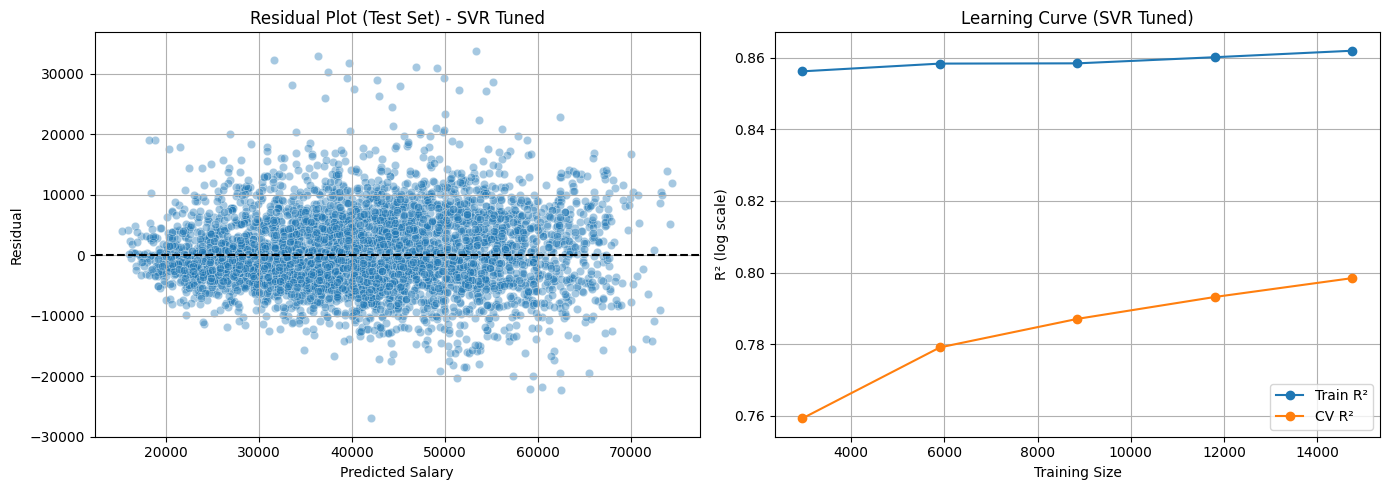

In [ ]:
import random
import warnings
import torch
import pandas as pd
import numpy as np
import pickle
import optuna
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import KFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import r2_score, make_scorer, mean_squared_error


from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import cross_validate, learning_curve
from sklearn.metrics import (
    r2_score,
    mean_squared_error,
    mean_absolute_error,
    make_scorer
)

# Machine Learning Models
from sklearn.svm import SVR


# REPRODUCIBILITY
seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)


# SCORERS AND SETUPS
cv = KFold(n_splits=5, shuffle=True, random_state=seed)

scoring = {
    "r2": "r2",
    "rmse": "neg_root_mean_squared_error"
}


def rmse_real(y_true, y_pred):
    y_true_real = np.expm1(y_true)
    y_pred_real = np.expm1(y_pred)
    return np.sqrt(mean_squared_error(y_true_real, y_pred_real))

rmse_real_scorer = make_scorer(rmse_real, greater_is_better=False)

# LOAD DATA
df = pd.read_csv(
    "../Unified_Resume_Salary_Dataset.csv"
)

with open("../master_vocab.pkl", "rb") as f:
    master_vocab = pickle.load(f)

train_idx = np.load("../train_idx.npy")
test_idx  = np.load("../test_idx.npy")

X_text = df["Aligned_Text"]
y = df["Log_Salary"]

X_train = X_text.iloc[train_idx]
X_test  = X_text.iloc[test_idx]

y_train = y.iloc[train_idx].values
y_test  = y.iloc[test_idx].values


# PIPELINE
tfidf_config = dict(
    vocabulary=master_vocab,
    ngram_range=(1, 3),
    token_pattern=r'(?u)\.?[a-z0-9][a-z0-9\+\#\.]*',
    norm=None,
    binary=True,
    min_df=5
)

# OPTUNA OBJECTIVE
def objective(trial):
    params = {
        "C": trial.suggest_float("C", 0.45, 0.60, log=True),
        "epsilon": trial.suggest_float("epsilon", 0.155, 0.190, log=True),
        "kernel": "rbf",
        "gamma": trial.suggest_float("gamma", 0.0045, 0.0065, log=True)
    }

    model = Pipeline([
        ("tfidf", TfidfVectorizer(**tfidf_config)),
        ("model", SVR(**params))
    ])

    cv_results = cross_validate(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring="r2",
        return_train_score=True,
        n_jobs=-1
    )

    score = np.mean(cv_results["test_score"])
    return score



study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=100)

best_params = study.best_params

# PRINT BEST PARAMETERS FIRST
print("\n" + "="*80)
print(" BEST OPTUNA PARAMETERS")
print("="*80)
for k, v in best_params.items():
    print(f"{k}: {v}")
print("="*80)

# FINAL MODEL
best_model = Pipeline([
    ("tfidf", TfidfVectorizer(**tfidf_config)),
    ("model", SVR(**best_params))
])

# CROSS VALIDATION (BEST MODEL)
cv_results = cross_validate(
    best_model,
    X_train,
    y_train,
    cv=cv,
    scoring={
        "r2": "r2",
        "rmse": "neg_root_mean_squared_error",
        "mae": "neg_mean_absolute_error"
    },
    return_train_score=True,
    n_jobs=-1
)

# PER-FOLD RESULTS TABLE
fold_df = pd.DataFrame({
    "Fold": np.arange(1, cv.get_n_splits() + 1),

    "Train_R2": cv_results["train_r2"],
    "Val_R2": cv_results["test_r2"],

    "Train_RMSE": -cv_results["train_rmse"],
    "Val_RMSE": -cv_results["test_rmse"],

    "Train_MAE": -cv_results["train_mae"],
    "Val_MAE": -cv_results["test_mae"]
})

print("\n=== PER FOLD RESULTS TABLE ===")
print(fold_df)

# METRICS (LOG SCALE - CV ONLY)
cv_train_r2 = np.mean(cv_results["train_r2"])
cv_val_r2   = np.mean(cv_results["test_r2"])

cv_train_rmse = -np.mean(cv_results["train_rmse"])
cv_val_rmse   = -np.mean(cv_results["test_rmse"])

cv_train_mae = -np.mean(cv_results["train_mae"])
cv_val_mae   = -np.mean(cv_results["test_mae"])

gap = cv_train_r2 - cv_val_r2

# PRINT PER MODEL SUMMARY
print("\n" + "="*70)
print(f"{'SVR (TUNED) - 5-FOLD CV (LOG SCALE)':^70}")
print("="*70)
print(f"{'Metric':<10}{'Train':>15}{'Validation':>15}{'Gap':>15}")
print("-"*70)
print(f"{'R²':<10}{cv_train_r2:>15.4f}{cv_val_r2:>15.4f}{gap:>15.4f}")
print(f"{'RMSE':<10}{cv_train_rmse:>15.4f}{cv_val_rmse:>15.4f}{'':>15}")
print(f"{'MAE':<10}{cv_train_mae:>15.4f}{cv_val_mae:>15.4f}{'':>15}")
print("="*70)

# TRAIN FINAL MODEL ON FULL TRAIN SET
best_model.fit(X_train, y_train)

# PREDICTIONS (LOG SCALE)
train_pred_log = best_model.predict(X_train)
test_pred_log  = best_model.predict(X_test)

# INVERSE TRANSFORM
train_pred = np.expm1(train_pred_log)
test_pred  = np.expm1(test_pred_log)

y_train_actual = np.expm1(y_train)
y_test_actual  = np.expm1(y_test)

# METRICS (ORIGINAL SCALE)
train_r2_orig = r2_score(y_train_actual, train_pred)
test_r2_orig  = r2_score(y_test_actual, test_pred)

train_rmse_orig = np.sqrt(mean_squared_error(y_train_actual, train_pred))
test_rmse_orig  = np.sqrt(mean_squared_error(y_test_actual, test_pred))

train_mae_orig = mean_absolute_error(y_train_actual, train_pred)
test_mae_orig  = mean_absolute_error(y_test_actual, test_pred)

# PRINT FINAL RESULTS
print("\n" + "="*70)
print(f"{'SVR (TUNED) - TRAIN & TEST (ORIGINAL SCALE)':^70}")
print("="*70)
print(f"{'Metric':<10}{'Train':>15}{'Test':>15}")
print("-"*70)
print(f"{'R²':<10}{train_r2_orig:>15.4f}{test_r2_orig:>15.4f}")
print(f"{'RMSE':<10}{train_rmse_orig:>15,.2f}{test_rmse_orig:>15,.2f}")
print(f"{'MAE':<10}{train_mae_orig:>15,.2f}{test_mae_orig:>15,.2f}")
print("="*70)


# PLOTS
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Residual Plot ---
residuals = y_test_actual - test_pred

sns.scatterplot(
    x=test_pred,
    y=residuals,
    alpha=0.4,
    ax=axes[0]
)

axes[0].axhline(0, linestyle='--', color='black')
axes[0].grid(True)
axes[0].set_title("Residual Plot (Test Set) - SVR Tuned")
axes[0].set_xlabel("Predicted Salary")
axes[0].set_ylabel("Residual")

# --- Learning Curve ---
train_sizes, train_scores, val_scores = learning_curve(
    best_model,
    X_train,
    y_train,
    cv=cv,
    scoring="r2",
    train_sizes=np.linspace(0.2, 1.0, 5),
    n_jobs=-1
)

axes[1].plot(train_sizes, np.mean(train_scores, axis=1), marker='o', label="Train R²")
axes[1].plot(train_sizes, np.mean(val_scores, axis=1), marker='o', label="CV R²")

axes[1].grid(True)
axes[1].set_title("Learning Curve (SVR Tuned)")
axes[1].set_xlabel("Training Size")
axes[1].set_ylabel("R² (log scale)")
axes[1].legend()

plt.tight_layout()
plt.show()